# 1. Install packages

In [1]:
%pip install -qU \
    langchain \
    langchain-core \
    langchain-groq \
    langchain-huggingface \
    langchain-pinecone \
    pinecone \
    sentence-transformers \
    pymupdf \
    groq \
    pandas \
    tabulate \
    pillow

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 79.5/79.5 kB 6.2 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 40.8/40.8 kB 3.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 163.7/163.7 kB 12.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 572.0/572.0 kB 37.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 587.6/587.6 kB 46.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 740.6/740.6 kB 55.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 25.8/25.8 MB 74.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 137.5/137.5 kB 13.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.8/10.8 MB 120.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 6.9/6.9 MB 118.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 125.9/125.9 kB 13.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 259.3/259.3 kB 26.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

In [2]:
%pip uninstall -y pillow
%pip install --no-cache-dir --force-reinstall pillow

Found existing installation: pillow 12.3.0
Uninstalling pillow-12.3.0:
  Successfully uninstalled pillow-12.3.0
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 6.9/6.9 MB 101.5 MB/s eta 0:00:00


# 2. Imports

In [1]:
import os
import io
import time
import base64
from pathlib import Path
from getpass import getpass

import fitz
import pandas as pd

from PIL import Image
from IPython.display import display

from groq import Groq

from pinecone import Pinecone, ServerlessSpec

from langchain_core.documents import Document
from langchain_core.prompts import ChatPromptTemplate
from langchain_core.output_parsers import StrOutputParser
from langchain_groq import ChatGroq
from langchain_huggingface import HuggingFaceEmbeddings
from langchain_pinecone import PineconeVectorStore

# 3. PDF and model configuration

In [2]:
PDF_PATH = Path("NovaCore_Multimodal_Company_Report_2026.pdf")

# Fallback for this generated environment.
if not PDF_PATH.exists():
    fallback = Path("/mnt/data/NovaCore_Multimodal_Company_Report_2026.pdf")
    if fallback.exists():
        PDF_PATH = fallback

assert PDF_PATH.exists(), (
    "PDF not found. Keep NovaCore_Multimodal_Company_Report_2026.pdf "
    "in the same folder as this notebook."
)

In [4]:
PDF_PATH

PosixPath('NovaCore_Multimodal_Company_Report_2026.pdf')

In [5]:
TEXT_MODEL = "openai/gpt-oss-20b"
VISION_MODEL = "qwen/qwen3.8-27b"
EMBEDDING_MODEL = "sentence-transformers/all-MiniLM-L6-v2"

PINECONE_INDEX_NAME = "novacore-multimodal-rag"
PINECONE_NAMESPACE = "fy2026-demo"

IMAGE_DIR = Path("novacore_extracted_images")
IMAGE_DIR.mkdir(exist_ok=True)

print("PDF:", PDF_PATH)
print("Pinecone index:", PINECONE_INDEX_NAME)
print("Pinecone namespace:", PINECONE_NAMESPACE)

PDF: NovaCore_Multimodal_Company_Report_2026.pdf
Pinecone index: novacore-multimodal-rag
Pinecone namespace: fy2026-demo


# 4. Add Groq and Pinecone API keys

In [ ]:
if not os.getenv("GROQ_API_KEY"):
    os.environ["GROQ_API_KEY"] = "your_groq_api_key_here"

if not os.getenv("PINECONE_API_KEY"):
    os.environ["PINECONE_API_KEY"] = "your_pinecone_api_key_here"

groq_client = Groq(api_key=os.environ["GROQ_API_KEY"])

text_llm = ChatGroq(
    model=TEXT_MODEL,
    temperature=0,
)

print("API clients are ready.")

API clients are ready.


# 5. Helper: convert image to base64

In [7]:
def image_to_data_uri(image_path):
    image_path = Path(image_path)

    with Image.open(image_path) as img:
        img = img.convert("RGB")
        img.thumbnail((1600, 1600))

        buffer = io.BytesIO()
        img.save(buffer, format="JPEG", quality=85)

    encoded = base64.b64encode(buffer.getvalue()).decode("utf-8")
    return f"data:image/jpeg;base64,{encoded}"

# 6. Helper: summarize images, charts, and diagrams

We do not embed raw images with the text embedding model.

Instead:

```text
Image / Chart
     ↓
Vision model
     ↓
Text summary
     ↓
Embedding
     ↓
Pinecone
```

We still keep the original image path so the final answer can use the real visual.

In [8]:
def summarize_visual(image_path, page_number):
    image_data = image_to_data_uri(image_path)

    prompt = f"""
This visual was extracted from page {page_number} of the NovaCore FY2026 company report.

Describe the useful business information visible in the visual.

If it is a chart or graph:
- mention important values
- mention highest/lowest values
- mention the main trend

If it is a diagram:
- identify important components
- explain the flow or relationships

If it is a normal business image:
- describe the useful factual information

Keep the description concise and factual.
"""

    response = groq_client.chat.completions.create(
        model=VISION_MODEL,
        messages=[
            {
                "role": "user",
                "content": [
                    {"type": "text", "text": prompt},
                    {
                        "type": "image_url",
                        "image_url": {"url": image_data},
                    },
                ],
            }
        ],
        temperature=0,
        max_completion_tokens=500,
    )

    return response.choices[0].message.content.strip()

# 7. Extract text, tables, and visuals from the PDF

In [9]:
def extract_multimodal_documents(pdf_path):
    pdf = fitz.open(str(pdf_path))

    documents = []
    extracted_xrefs = set()

    for page_index in range(len(pdf)):
        page = pdf[page_index]
        page_number = page_index + 1

        print(f"Processing page {page_number}...")

        # -------------------------------------------------
        # 1. TEXT
        # -------------------------------------------------
        text = page.get_text("text").strip()

        if text:
            documents.append(
                Document(
                    page_content=text,
                    metadata={
                        "page": page_number,
                        "modality": "text",
                        "source": pdf_path.name,
                    },
                )
            )

        # -------------------------------------------------
        # 2. TABLES
        # -------------------------------------------------
        try:
            tables = page.find_tables().tables

            for table_number, table in enumerate(tables, start=1):
                df = table.to_pandas()

                if not df.empty:
                    table_text = df.to_markdown(index=False)

                    documents.append(
                        Document(
                            page_content=table_text,
                            metadata={
                                "page": page_number,
                                "modality": "table",
                                "table_number": table_number,
                                "source": pdf_path.name,
                            },
                        )
                    )

        except Exception as error:
            print("Table extraction warning:", error)

        # -------------------------------------------------
        # 3. IMAGES / CHARTS / DIAGRAMS
        # -------------------------------------------------
        for image_number, image_info in enumerate(
            page.get_images(full=True),
            start=1,
        ):
            xref = image_info[0]

            # Do not process an identical embedded image twice.
            if xref in extracted_xrefs:
                continue

            extracted_xrefs.add(xref)

            image_data = pdf.extract_image(xref)
            image_bytes = image_data["image"]
            image_extension = image_data["ext"]

            image_path = (
                IMAGE_DIR
                / f"page_{page_number}_image_{image_number}.{image_extension}"
            )

            image_path.write_bytes(image_bytes)

            try:
                summary = summarize_visual(
                    image_path=image_path,
                    page_number=page_number,
                )

                documents.append(
                    Document(
                        page_content=summary,
                        metadata={
                            "page": page_number,
                            "modality": "visual",
                            "image_path": str(image_path),
                            "source": pdf_path.name,
                        },
                    )
                )

            except Exception as error:
                print(
                    f"Vision warning on page {page_number}:",
                    error,
                )

    pdf.close()
    return documents


documents = extract_multimodal_documents(PDF_PATH)

print()
print("Total LangChain documents:", len(documents))

Processing page 1...
Consider using the pymupdf_layout package for a greatly improved page layout analysis.
Processing page 2...
Processing page 3...
Processing page 4...
Processing page 5...
Processing page 6...
Processing page 7...
Processing page 8...
Processing page 9...

Total LangChain documents: 24


In [10]:
documents

[Document(metadata={'page': 1, 'modality': 'text', 'source': 'NovaCore_Multimodal_Company_Report_2026.pdf'}, page_content='NovaCore Systems Ltd. - Fictional company report created for a multimodal RAG demonstration\nPage 1\nNOVACORE SYSTEMS LTD.\nFY2026 BUSINESS PERFORMANCE &\nOPERATIONS REPORT\nA realistic fictional company document designed for multimodal RAG testing\nHeadquarters\nSingapore\nEmployees\n1,480\n2026 Revenue\n$132.0M\nOperating Margin\n18.4%\nPrimary Sector\nIndustrial AI & IoT\nMarkets Served\n42 countries\nDemo note: All company names, metrics, people, and events in this report are fictional. The document intentionally mixes text, tables,\ncharts, and embedded images so it can be used to demonstrate multimodal retrieval and question answering.'),
 Document(metadata={'page': 1, 'modality': 'table', 'table_number': 1, 'source': 'NovaCore_Multimodal_Company_Report_2026.pdf'}, page_content='| Headquarters   | Singapore           | Employees        | 1,480        |\n|:---

# 8. Inspect extracted content

In [11]:
rows = []

for doc in documents:
    rows.append(
        {
            "page": doc.metadata["page"],
            "modality": doc.metadata["modality"],
            "preview": doc.page_content[:140].replace("\n", " "),
        }
    )

summary_df = pd.DataFrame(rows)

display(summary_df)

print("Documents by modality:")
display(summary_df["modality"].value_counts())

,page,modality,preview
0,1,text,NovaCore Systems Ltd. - Fictional company repo...
1,1,table,| Headquarters | Singapore | Emplo...
2,1,visual,Based on the visual from the NovaCore FY2026 c...
3,2,text,NovaCore Systems Ltd. - Fictional company repo...
4,2,table,| Priority | 2026 target ...
5,3,text,NovaCore Systems Ltd. - Fictional company repo...
6,3,table,| Metric | FY2025 | FY2026 | Cha...
7,3,visual,"Based on the visual provided, here is the desc..."
8,4,text,NovaCore Systems Ltd. - Fictional company repo...
9,4,table,| Region | 2026 revenue | YoY growth ...


Documents by modality:


modality
text      9
table     8
visual    7
Name: count, dtype: int64

# 9. Create  embeddings

In [12]:
embeddings = HuggingFaceEmbeddings(
    model_name=EMBEDDING_MODEL,
    encode_kwargs={"normalize_embeddings": True},
)

# Detect the exact vector dimension automatically.
EMBEDDING_DIMENSION = len(
    embeddings.embed_query("dimension check")
)

print("Embedding model:", EMBEDDING_MODEL)
print("Embedding dimension:", EMBEDDING_DIMENSION)

modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/116 [00:00<?, ?B/s]

README.md:   0%|          | 0.00/10.5k [00:00<?, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/612 [00:00<?, ?B/s]

...

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/466k [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

Embedding model: sentence-transformers/all-MiniLM-L6-v2
Embedding dimension: 384


# 10. Create the Pinecone serverless index

In [13]:
pc = Pinecone(
    api_key=os.environ["PINECONE_API_KEY"]
)

if not pc.has_index(PINECONE_INDEX_NAME):
    print("Creating Pinecone index...")

    pc.create_index(
        name=PINECONE_INDEX_NAME,
        dimension=EMBEDDING_DIMENSION,
        metric="cosine",
        spec=ServerlessSpec(
            cloud="aws",
            region="us-east-1",
        ),
    )

    # Wait until Pinecone reports that the index is ready.
    while not pc.describe_index(PINECONE_INDEX_NAME).status["ready"]:
        print("Waiting for Pinecone index...")
        time.sleep(2)

    print("Pinecone index created.")
else:
    print("Pinecone index already exists.")

index = pc.Index(PINECONE_INDEX_NAME)

print("Connected to:", PINECONE_INDEX_NAME)

Creating Pinecone index...
Pinecone index created.
Connected to: novacore-multimodal-rag


# 1. Clean the demo namespace

In [14]:
try:
    index.delete(
        delete_all=True,
        namespace=PINECONE_NAMESPACE,
    )

    print("Cleared namespace:", PINECONE_NAMESPACE)

except Exception as error:
    print(
        "Namespace was probably empty. Continuing...",
        error,
    )

Namespace was probably empty. Continuing... (404)
Reason: Not Found
HTTP response headers: HTTPHeaderDict({'Date': 'Tue, 22 Sep 2026 01:00:50 GMT', 'Content-Type': 'application/json', 'Content-Length': '55', 'Connection': 'keep-alive', 'x-pinecone-request-latency-ms': '44', 'x-envoy-upstream-service-time': '48', 'x-pinecone-response-duration-ms': '49', 'server': 'envoy'})
HTTP response body: {"code":5,"message":"Namespace not found","details":[]}



# 2. Store LangChain documents in Pinecone

Now the vector database step is:

```text
LangChain Documents
        ↓
Hugging Face Embeddings
        ↓
PineconeVectorStore
        ↓
Pinecone
```

In [15]:
vectorstore = PineconeVectorStore(
    index_name=PINECONE_INDEX_NAME,
    embedding=embeddings,
    namespace=PINECONE_NAMESPACE,
)

vectorstore.add_documents(documents)

print("Documents uploaded to Pinecone.")

Documents uploaded to Pinecone.


# 13. Create the Pinecone retriever

In [16]:
retriever = vectorstore.as_retriever(
    search_kwargs={"k": 5}
)

print("Retriever is ready.")

Retriever is ready.


# 14. Test Pinecone retrieval

In [17]:
query = "Which region had the highest revenue growth?"

retrieved_docs = retriever.invoke(query)

for i, doc in enumerate(retrieved_docs, start=1):
    print("=" * 80)
    print(
        f"Result {i} | "
        f"Page {doc.metadata.get('page')} | "
        f"Type: {doc.metadata.get('modality')}"
    )
    print(doc.page_content[:700])
    print()

Result 1 | Page 4.0 | Type: table
| Region        | 2026 revenue   | YoY growth   |   Enterprise customers | CSAT   |
|:--------------|:---------------|:-------------|-----------------------:|:-------|
| Europe        | $41.2M         | 31%          |                    118 | 4.7/5  |
| North America | $38.6M         | 27%          |                    104 | 4.6/5  |
| Asia Pacific  | $34.9M         | 24%          |                     96 | 4.8/5  |
| Middle East   | $17.3M         | 18%          |                     51 | 4.5/5  |

Result 2 | Page 4.0 | Type: visual
Based on the visual provided, here is the description of the business information:

**Chart Type:** Bar Chart
**Title:** 2026 Year-over-Year Revenue Growth by Region

**Key Data Points:**
The chart displays the projected revenue growth percentages for four specific geographic regions for the fiscal year 2026:
*   **Europe:** 31%
*   **North America:** 27%
*   **Asia Pacific:** 24%
*   **Middle East:** 18%

**Analysis:**
* 

# 15. Create the LangChain text RAG chain

For text and tables:

```text
Question
   ↓
Pinecone Retriever
   ↓
Relevant Context
   ↓
Prompt
   ↓
Text LLM
   ↓
Answer
```

In [18]:
rag_prompt = ChatPromptTemplate.from_template(
    """
You are a helpful assistant answering questions about the
NovaCore Systems FY2026 company report.

Use ONLY the retrieved context below.

If the answer is not available in the context, say:
"I could not find that information in the report."

Mention page numbers when possible.

CONTEXT:
{context}

QUESTION:
{question}

ANSWER:
"""
)

text_rag_chain = (
    rag_prompt
    | text_llm
    | StrOutputParser()
)

print("Text RAG chain is ready.")

Text RAG chain is ready.


# 16. Format retrieved context

In [19]:
def format_context(retrieved_docs):
    parts = []

    for doc in retrieved_docs:
        page = doc.metadata.get("page")
        modality = doc.metadata.get("modality")

        parts.append(
            f"[Page {page} | {modality.upper()}]\n"
            f"{doc.page_content}"
        )

    return "\n\n".join(parts)

# 17. Vision answer helper

If Pinecone retrieves visual evidence:

```text
Pinecone retrieves visual summary
            ↓
Read image_path from metadata
            ↓
Load the original image
            ↓
Question + context + image
            ↓
Vision model
```

In [20]:
def answer_with_vision(question, context, image_paths):
    image_paths = image_paths[:3]

    content = [
        {
            "type": "text",
            "text": f"""
You are answering questions about the NovaCore Systems FY2026 report.

Use ONLY the retrieved context and the attached retrieved visuals.

RETRIEVED CONTEXT:
{context}

QUESTION:
{question}

Instructions:
- Answer factually.
- Use the attached visuals when relevant.
- Mention page numbers.
- If the information is missing, say you could not find it.
""",
        }
    ]

    for image_path in image_paths:
        content.append(
            {
                "type": "image_url",
                "image_url": {
                    "url": image_to_data_uri(image_path)
                },
            }
        )

    response = groq_client.chat.completions.create(
        model=VISION_MODEL,
        messages=[
            {
                "role": "user",
                "content": content,
            }
        ],
        temperature=0,
        max_completion_tokens=900,
    )

    return response.choices[0].message.content.strip()

# 18. Complete Multimodal RAG function

This is the complete application:

```text
Question
   ↓
Pinecone Retriever
   ↓
Top 5 documents
   ↓
Any visual?
   ├── No  → Text RAG chain
   └── Yes → Vision LLM + retrieved images
   ↓
Final answer
```

In [21]:
def ask_rag(question, show_sources=True, show_images=False):

    # 1. Retrieve from Pinecone
    retrieved_docs = retriever.invoke(question)

    # 2. Create context
    context = format_context(retrieved_docs)

    # 3. Check whether Pinecone returned visuals
    image_paths = []

    for doc in retrieved_docs:
        if doc.metadata.get("modality") == "visual":
            image_path = doc.metadata.get("image_path")

            if image_path and Path(image_path).exists():
                image_paths.append(image_path)

    # 4. Generate the answer
    if image_paths:
        answer = answer_with_vision(
            question=question,
            context=context,
            image_paths=image_paths,
        )
    else:
        answer = text_rag_chain.invoke(
            {
                "context": context,
                "question": question,
            }
        )

    print("\nQUESTION:")
    print(question)

    print("\nANSWER:")
    print(answer)

    if show_sources:
        print("\nPINECONE RETRIEVED SOURCES:")

        for i, doc in enumerate(retrieved_docs, start=1):
            print(
                f"{i}. Page {doc.metadata.get('page')} "
                f"| {doc.metadata.get('modality')}"
            )

    if show_images and image_paths:
        print("\nRETRIEVED VISUALS:")

        for image_path in image_paths:
            display(Image.open(image_path))

    return {
        "answer": answer,
        "documents": retrieved_docs,
        "image_paths": image_paths,
    }

# 19. Demo — Text question

In [22]:
ask_rag(
    "What does NovaCore Systems do and where is the company headquartered?"
)


QUESTION:
What does NovaCore Systems do and where is the company headquartered?

ANSWER:
NovaCore Systems Ltd. develops industrial AI gateways, computer‑vision appliances, and connected sensor hubs for manufacturing, logistics, and energy companies【Page 2.0】. The company is headquartered in Singapore【Page 1.0】.

PINECONE RETRIEVED SOURCES:
1. Page 6.0 | text
2. Page 1.0 | text
3. Page 8.0 | text
4. Page 2.0 | text
5. Page 5.0 | text


{'answer': 'NovaCore Systems Ltd. develops industrial AI gateways, computer‑vision appliances, and connected sensor hubs for manufacturing, logistics, and energy companies【Page\u202f2.0】. The company is headquartered in Singapore【Page\u202f1.0】.',
 'documents': [Document(id='65e7cdb1-c6b1-4c63-98a3-eb9928b27bbd', metadata={'modality': 'text', 'page': 6.0, 'source': 'NovaCore_Multimodal_Company_Report_2026.pdf'}, page_content='NovaCore Systems Ltd. - Fictional company report created for a multimodal RAG demonstration\nPage 6\n5. Manufacturing & Supply Chain\nInformation-bearing diagram + facility image\nThe supply-chain diagram above contains operational details that are not repeated in full elsewhere. In particular, it\nidentifies the Quality Lab in Singapore as the critical control point before products move to regional distribution\nhubs.\nFigure 3. Penang Smart Assembly Facility. The embedded image carries facility utilization and solar contribution values that can be\nqueried by a 

# 20. Demo — Table question

In [23]:
ask_rag(
    "Which region had the highest year-over-year revenue growth?"
)


QUESTION:
Which region had the highest year-over-year revenue growth?

ANSWER:
Based on the bar chart titled "2026 Year-over-Year Revenue Growth by Region" and the accompanying table on **Page 4.0**, **Europe** had the highest year-over-year revenue growth at **31%**.

PINECONE RETRIEVED SOURCES:
1. Page 4.0 | visual
2. Page 4.0 | table
3. Page 2.0 | table
4. Page 3.0 | visual
5. Page 3.0 | table


{'answer': 'Based on the bar chart titled "2026 Year-over-Year Revenue Growth by Region" and the accompanying table on **Page 4.0**, **Europe** had the highest year-over-year revenue growth at **31%**.',
 'documents': [Document(id='b1bb2b74-014c-4f56-b21a-a67803653cbe', metadata={'image_path': 'novacore_extracted_images/page_4_image_1.png', 'modality': 'visual', 'page': 4.0, 'source': 'NovaCore_Multimodal_Company_Report_2026.pdf'}, page_content='Based on the visual provided, here is the description of the business information:\n\n**Chart Type:** Bar Chart\n**Title:** 2026 Year-over-Year Revenue Growth by Region\n\n**Key Data Points:**\nThe chart displays the projected revenue growth percentages for four specific geographic regions for the fiscal year 2026:\n*   **Europe:** 31%\n*   **North America:** 27%\n*   **Asia Pacific:** 24%\n*   **Middle East:** 18%\n\n**Analysis:**\n*   **Highest Value:** Europe is projected to have the highest year-over-year revenue growth at 31%.\n*   **Lowes

# 21. Demo — Revenue graph


QUESTION:
According to the revenue graph, which quarter had the highest revenue?

ANSWER:
Based on the "Quarterly Revenue Trend" line graph on Page 3.0, the quarter with the highest revenue is **Q4 2026**. The graph shows a consistent upward trend, with Q4 2026 reaching the peak value of approximately $37.5 million.

PINECONE RETRIEVED SOURCES:
1. Page 3.0 | visual
2. Page 4.0 | visual
3. Page 4.0 | table
4. Page 3.0 | table
5. Page 3.0 | text

RETRIEVED VISUALS:


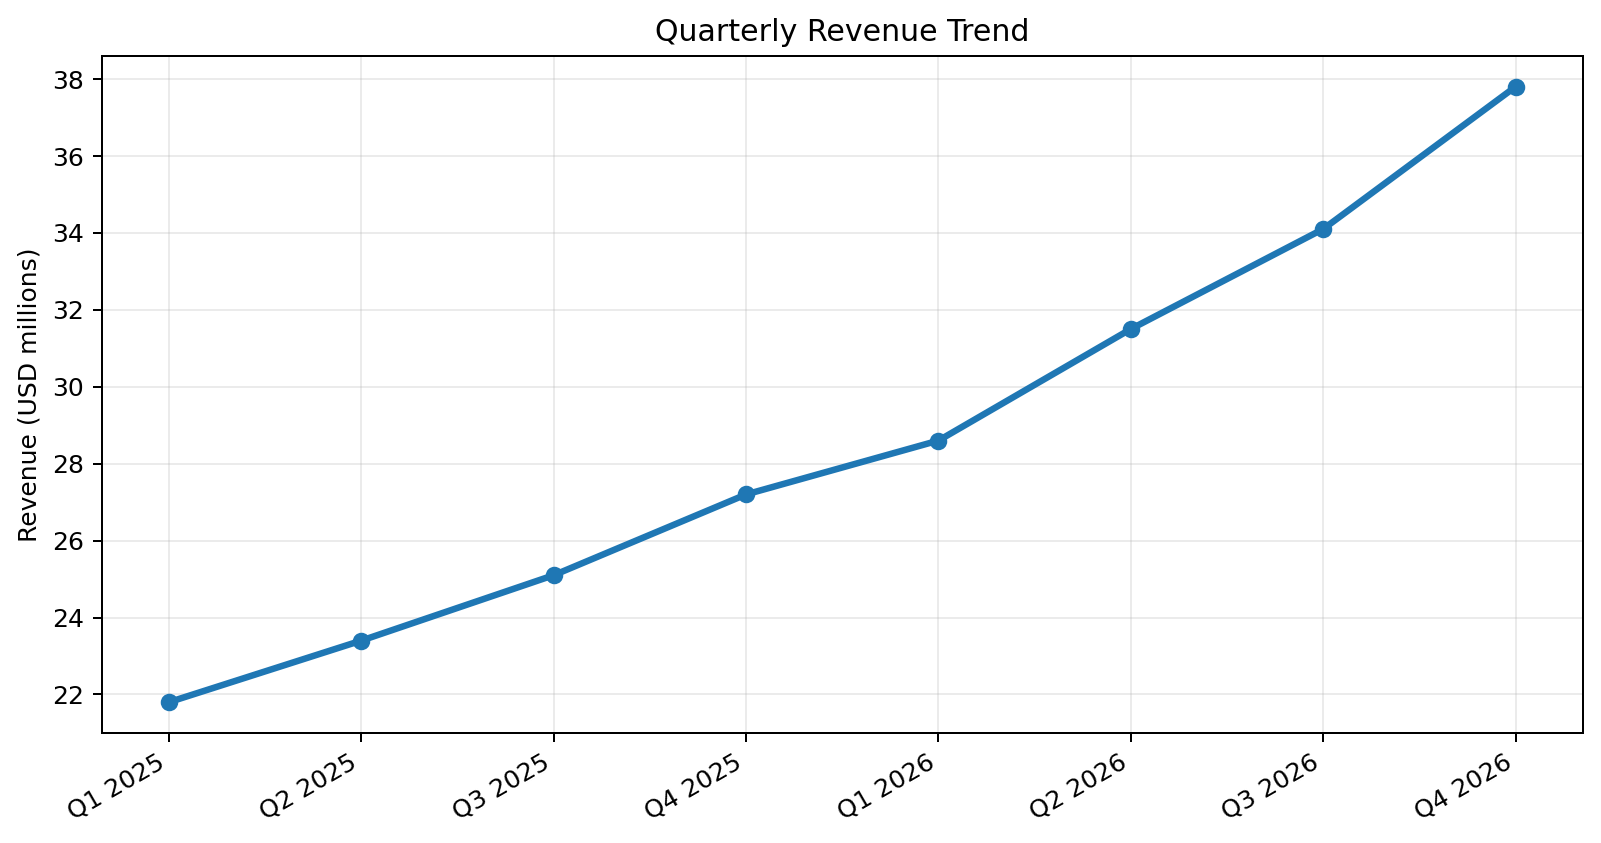

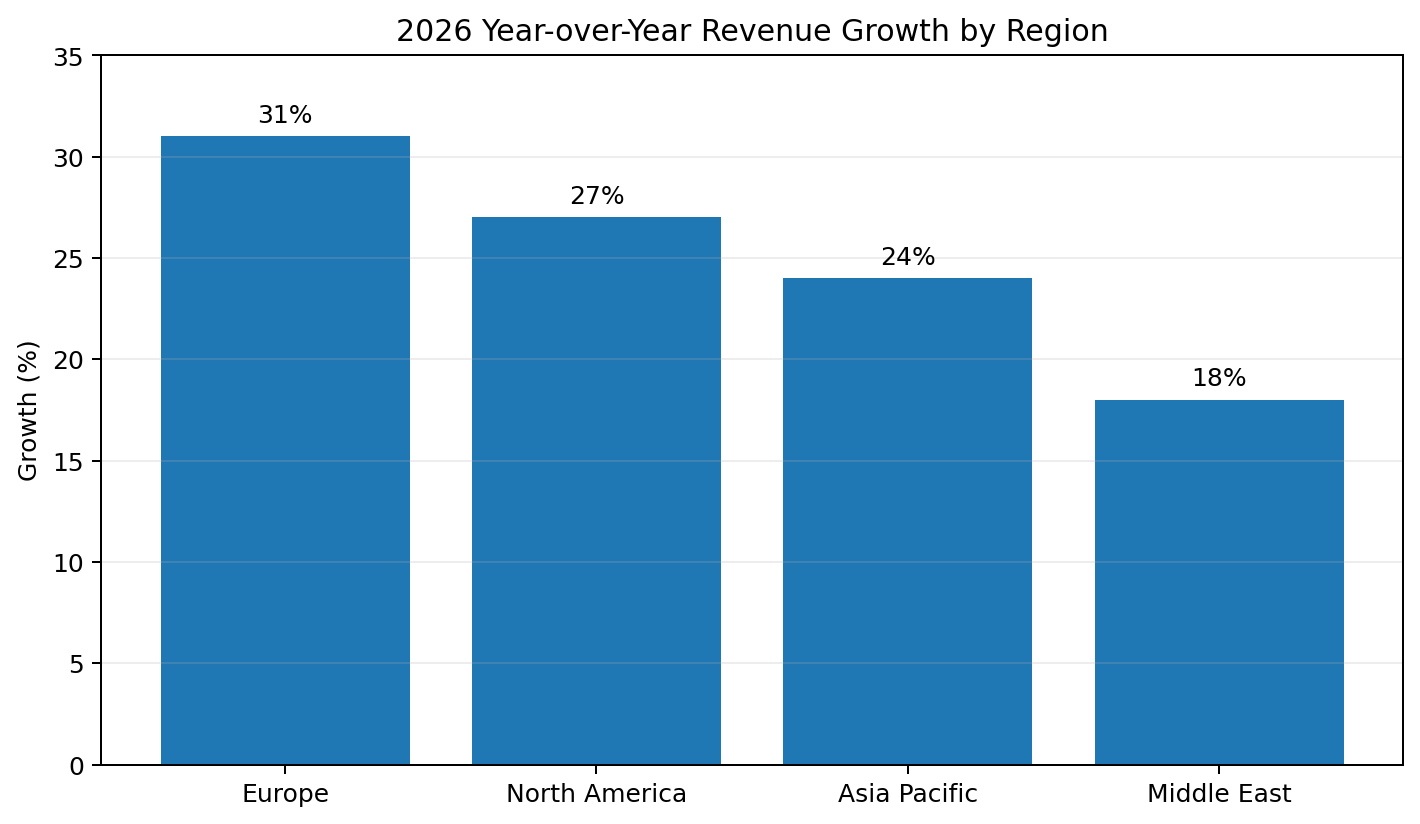

{'answer': 'Based on the "Quarterly Revenue Trend" line graph on Page 3.0, the quarter with the highest revenue is **Q4 2026**. The graph shows a consistent upward trend, with Q4 2026 reaching the peak value of approximately $37.5 million.',
 'documents': [Document(id='a2ee9f5e-9940-4594-b09a-74660faa2c8d', metadata={'image_path': 'novacore_extracted_images/page_3_image_1.png', 'modality': 'visual', 'page': 3.0, 'source': 'NovaCore_Multimodal_Company_Report_2026.pdf'}, page_content='Based on the visual provided, here is the description of the business information:\n\n**Chart Type:** Line Graph\n**Title:** Quarterly Revenue Trend\n\n**Key Data Points (Revenue in USD millions):**\n*   **Q1 2025:** ~22.0 (Lowest value)\n*   **Q2 2025:** ~23.5\n*   **Q3 2025:** ~25.2\n*   **Q4 2025:** ~27.2\n*   **Q1 2026:** ~28.5\n*   **Q2 2026:** ~31.5\n*   **Q3 2026:** ~34.1\n*   **Q4 2026:** ~37.5 (Highest value)\n\n**Main Trend:**\nThe chart displays a consistent and strong upward trend in revenue ove

In [24]:
ask_rag(
    "According to the revenue graph, which quarter had the highest revenue?",
    show_images=True,
)

# 22. Demo — Supply-chain diagram


QUESTION:
According to the supply-chain diagram, what is the critical quality-control point?

ANSWER:
Based on the supply-chain diagram on **Page 6.0**, the critical quality-control point is the **Quality Lab** located in **Singapore**.

The diagram explicitly highlights this stage with a green box labeled "Critical control point: Quality Lab" and notes that "Every production batch must pass thermal, network, and firmware tests before export."

PINECONE RETRIEVED SOURCES:
1. Page 6.0 | visual
2. Page 6.0 | text
3. Page 9.0 | table
4. Page 7.0 | table
5. Page 8.0 | table

RETRIEVED VISUALS:


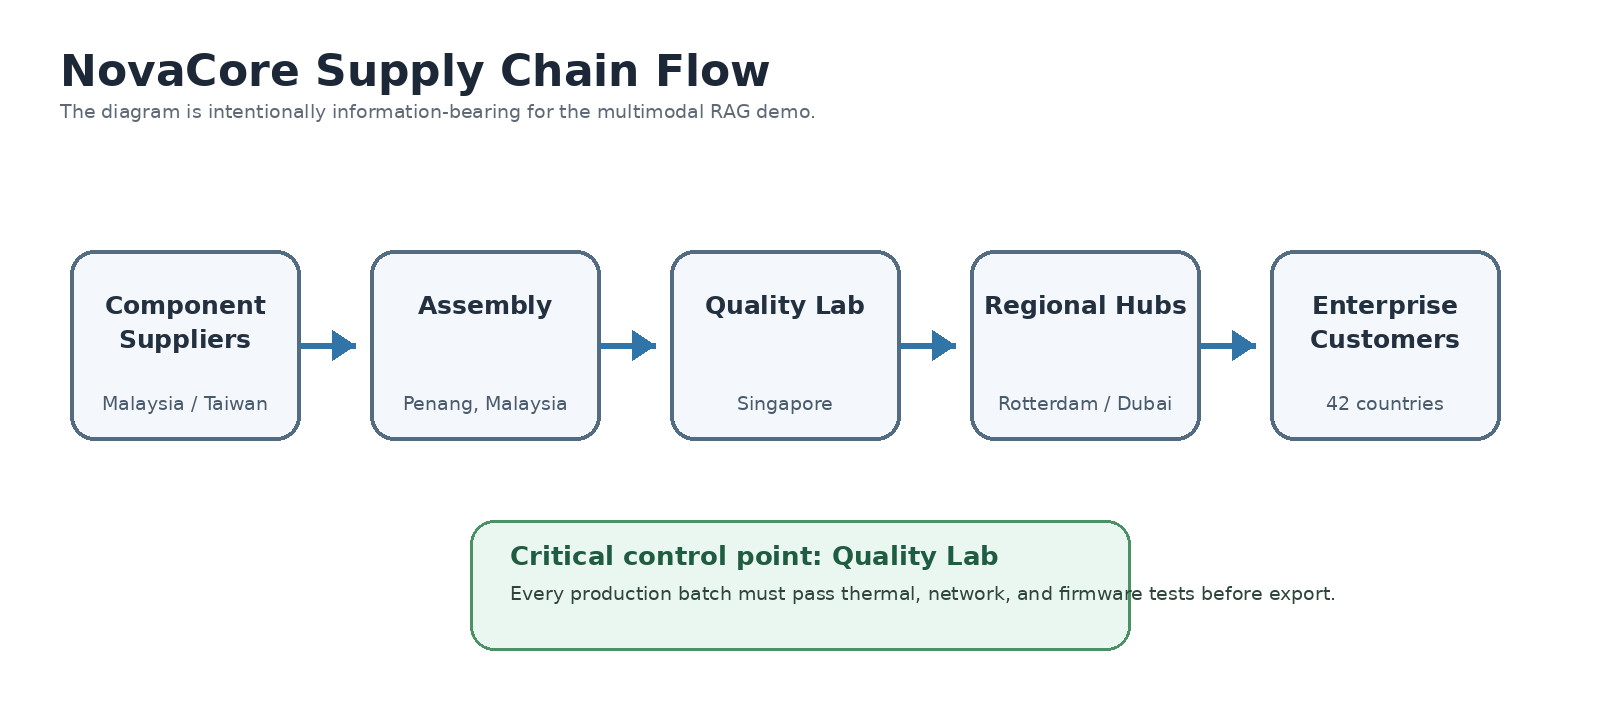

{'answer': 'Based on the supply-chain diagram on **Page 6.0**, the critical quality-control point is the **Quality Lab** located in **Singapore**.\n\nThe diagram explicitly highlights this stage with a green box labeled "Critical control point: Quality Lab" and notes that "Every production batch must pass thermal, network, and firmware tests before export."',
 'documents': [Document(id='14255e8c-98af-4ccd-954a-529a0cb9fe11', metadata={'image_path': 'novacore_extracted_images/page_6_image_1.png', 'modality': 'visual', 'page': 6.0, 'source': 'NovaCore_Multimodal_Company_Report_2026.pdf'}, page_content='Based on the visual provided, here is the description of the business information:\n\n**Diagram Type:** Supply Chain Flow Diagram\n\n**Title:** NovaCore Supply Chain Flow\n\n**Flow and Relationships:**\nThe diagram illustrates a linear, five-stage supply chain process moving from left to right:\n\n1.  **Component Suppliers:** The starting point of the supply chain, located in **Malaysia / 

In [25]:
ask_rag(
    "According to the supply-chain diagram, what is the critical quality-control point?",
    show_images=True,
)

# 23. Demo — Support resolution graph


QUESTION:
How did average support resolution time change from January to August?

ANSWER:
Based on the NovaCore Systems FY2026 report, the average support resolution time decreased significantly from January to August.

*   **January:** The average resolution time was **14.2 hours**.
*   **August:** The average resolution time dropped to **8.1 hours**.

This represents a total reduction of **6.1 hours** over the seven-month period. As shown in the line graph on **Page 7**, the trend was consistently downward, with the time decreasing month-over-month. The text on **Page 7** notes that this improvement coincided with the introduction of automated case classification in March and a retrieval-assisted troubleshooting copilot in May. Additionally, **Page 2** confirms that the company achieved its 2026 target of an average resolution time of less than 9 hours in July.

PINECONE RETRIEVED SOURCES:
1. Page 7.0 | visual
2. Page 7.0 | text
3. Page 7.0 | table
4. Page 2.0 | table
5. Page 3.0 | 

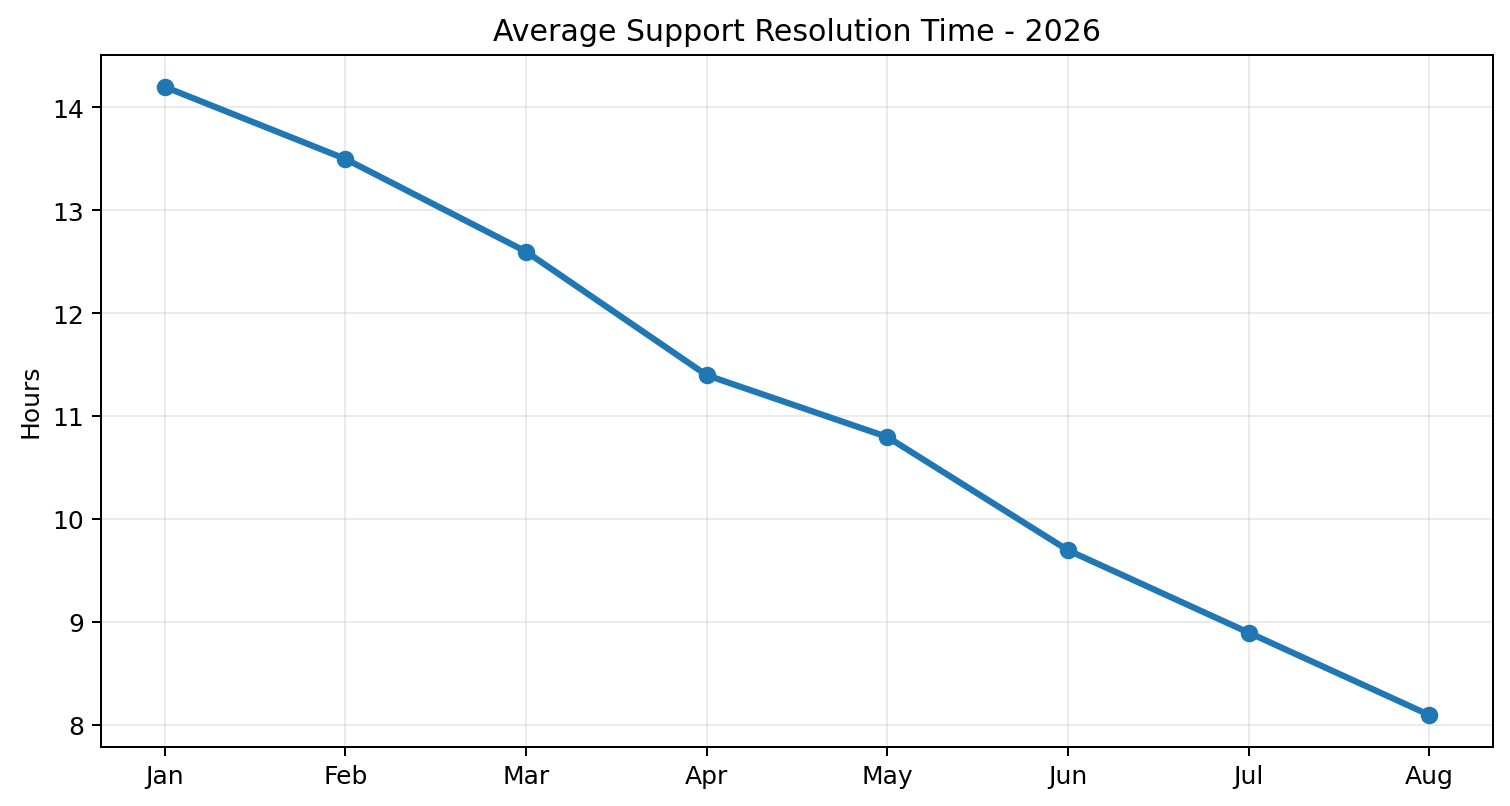

{'answer': 'Based on the NovaCore Systems FY2026 report, the average support resolution time decreased significantly from January to August.\n\n*   **January:** The average resolution time was **14.2 hours**.\n*   **August:** The average resolution time dropped to **8.1 hours**.\n\nThis represents a total reduction of **6.1 hours** over the seven-month period. As shown in the line graph on **Page 7**, the trend was consistently downward, with the time decreasing month-over-month. The text on **Page 7** notes that this improvement coincided with the introduction of automated case classification in March and a retrieval-assisted troubleshooting copilot in May. Additionally, **Page 2** confirms that the company achieved its 2026 target of an average resolution time of less than 9 hours in July.',
 'documents': [Document(id='c04596e3-9ec7-484d-9849-d912af0e19f2', metadata={'image_path': 'novacore_extracted_images/page_7_image_1.png', 'modality': 'visual', 'page': 7.0, 'source': 'NovaCore_M

In [26]:
ask_rag(
    "How did average support resolution time change from January to August?",
    show_images=True,
)

# 24. Demo — Sustainability chart


QUESTION:
What percentage of electricity at the Penang facility came from solar?

ANSWER:
Based on the pie chart titled "Penang Facility Electricity Mix - 2026" on page 8.0, solar electricity accounted for **34%** of the total electricity at the Penang facility. This is also confirmed in the facility overview on page 1.0, which states "Solar contribution to electricity: 34%".

PINECONE RETRIEVED SOURCES:
1. Page 8.0 | visual
2. Page 8.0 | text
3. Page 1.0 | visual
4. Page 8.0 | table
5. Page 1.0 | table

RETRIEVED VISUALS:


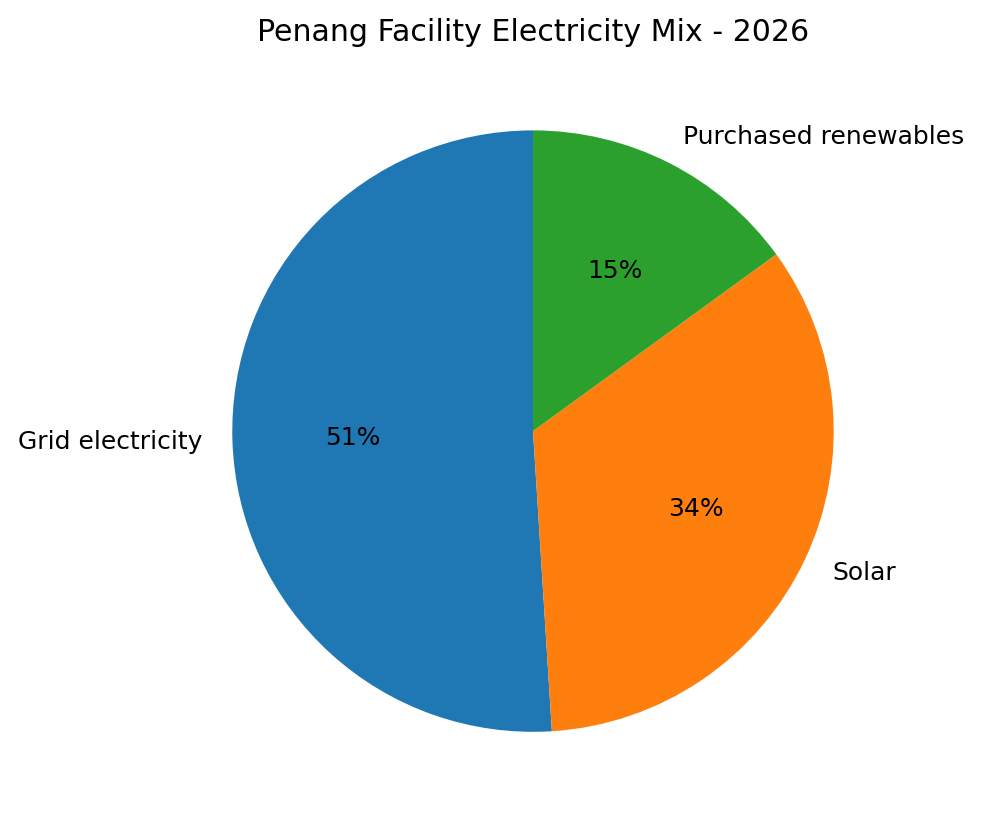

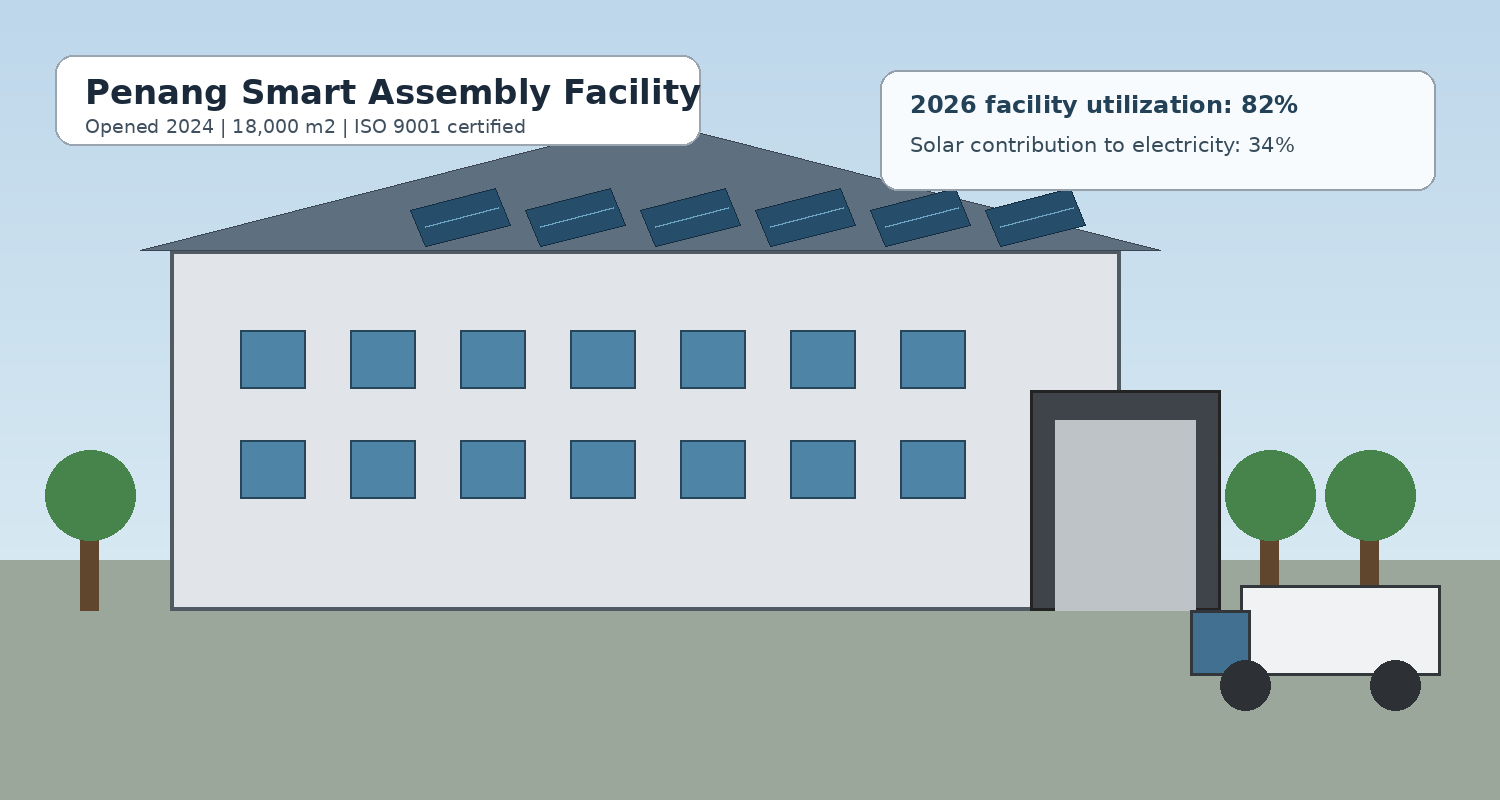

{'answer': 'Based on the pie chart titled "Penang Facility Electricity Mix - 2026" on page 8.0, solar electricity accounted for **34%** of the total electricity at the Penang facility. This is also confirmed in the facility overview on page 1.0, which states "Solar contribution to electricity: 34%".',
 'documents': [Document(id='8003e584-6665-4bc8-aace-56f0537776ab', metadata={'image_path': 'novacore_extracted_images/page_8_image_1.png', 'modality': 'visual', 'page': 8.0, 'source': 'NovaCore_Multimodal_Company_Report_2026.pdf'}, page_content='Based on the visual provided, here is the description of the business information:\n\n**Chart Type:** Pie Chart\n**Title:** Penang Facility Electricity Mix - 2026\n\n**Key Data Points:**\nThe chart breaks down the electricity sources for the Penang facility for the year 2026 into three categories:\n\n*   **Grid electricity:** 51% (The largest portion, represented in blue)\n*   **Solar:** 34% (The second largest portion, represented in orange)\n*  

In [27]:
ask_rag(
    "What percentage of electricity at the Penang facility came from solar?",
    show_images=True,
)

# 25. Demo — Cross-modal question

In [28]:
ask_rag(
    """
Give me a short FY2026 performance summary.
Include:
1. total revenue,
2. fastest-growing region,
3. support-resolution improvement,
4. solar share at the Penang facility.
"""
)


QUESTION:

Give me a short FY2026 performance summary.
Include:
1. total revenue,
2. fastest-growing region,
3. support-resolution improvement,
4. solar share at the Penang facility.


ANSWER:
Here is a short FY2026 performance summary for NovaCore Systems:

*   **Total Revenue:** FY2026 revenue reached **$132.0 million**, representing a 35.4% increase from the previous year (Page 3).
*   **Fastest-Growing Region:** **Europe** was the fastest-growing region, achieving 31% year-over-year revenue growth (Page 2).
*   **Support-Resolution Improvement:** The company achieved its target of an average resolution time under 9 hours, reaching **8.1 hours in August** (Page 2).
*   **Solar Share at Penang Facility:** Solar energy accounted for **34%** of the electricity mix at the Penang facility (Page 1, Page 8).

PINECONE RETRIEVED SOURCES:
1. Page 1.0 | visual
2. Page 3.0 | text
3. Page 2.0 | text
4. Page 8.0 | visual
5. Page 2.0 | table


{'answer': 'Here is a short FY2026 performance summary for NovaCore Systems:\n\n*   **Total Revenue:** FY2026 revenue reached **$132.0 million**, representing a 35.4% increase from the previous year (Page 3).\n*   **Fastest-Growing Region:** **Europe** was the fastest-growing region, achieving 31% year-over-year revenue growth (Page 2).\n*   **Support-Resolution Improvement:** The company achieved its target of an average resolution time under 9 hours, reaching **8.1 hours in August** (Page 2).\n*   **Solar Share at Penang Facility:** Solar energy accounted for **34%** of the electricity mix at the Penang facility (Page 1, Page 8).',
 'documents': [Document(id='05d07b37-929f-4e91-9499-6378cba9b7b5', metadata={'image_path': 'novacore_extracted_images/page_1_image_1.png', 'modality': 'visual', 'page': 1.0, 'source': 'NovaCore_Multimodal_Company_Report_2026.pdf'}, page_content='Based on the visual from the NovaCore FY2026 company report, here is the useful business information:\n\n**Facil